In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
from nltk.tokenize import word_tokenize

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/My Drive/NLP/dataset_verb.xlsx')
print(df.head())
print(df.isnull().sum())

df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'], axis=1)
print(df.head())

                      Sentence   Sentiment Unnamed: 2  Unnamed: 3 Unnamed: 4  \
0   আমি নিজের ভুল স্বীকার করি।  Transitive        NaN         NaN        NaN   
1  সে নিজের কাজের জন্য গর্বিত।  Transitive        NaN         NaN        NaN   
2        তারা দুঃখ প্রকাশ করে।  Transitive        NaN         NaN        NaN   
3           তুমি সঠিক কথা বলো।  Transitive        NaN         NaN        NaN   
4  আমি শান্ত থাকার চেষ্টা করি।  Transitive        NaN         NaN        NaN   

   Unnamed: 5 Unnamed: 6  
0         NaN        NaN  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN        NaN  
Sentence         1
Sentiment        1
Unnamed: 2    2614
Unnamed: 3    2616
Unnamed: 4    2615
Unnamed: 5    2616
Unnamed: 6    2615
dtype: int64
                      Sentence   Sentiment
0   আমি নিজের ভুল স্বীকার করি।  Transitive
1  সে নিজের কাজের জন্য গর্বিত।  Transitive
2        তারা দুঃখ প্রকাশ করে।  Transitive
3           তুমি সঠিক কথা বলো।  Transit

In [ ]:
def clean_Sentence(content):
    if not isinstance(content, str):
        return content

    content = re.sub(r"[০-৯]+", " ", content)
    content = content.replace("।", " ")
    content = re.sub(r"[a-zA-Z0-9]+", " ", content)
    content = re.sub(r"[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF]+", " ", content)
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U00002764"
        u"\U0001F5A4"
        "]+", flags=re.UNICODE)
    content = emoji_pattern.sub("", content)
    content = re.sub(r"[()\[\]{}!\"#$%&'()*+,\-./:;<=>?@\\^_`|~—–]+", " ", content)
    content = re.sub(r'https?://\S+|www\.\S+', ' ', content)
    content = re.sub(r'\s+', ' ', content).strip()

    return content

In [ ]:
df["clean_Sentence"] = df["Sentence"].apply(lambda x: clean_Sentence (x))
df.head()

,Sentence,Sentiment,clean_Sentence
0,আমি নিজের ভুল স্বীকার করি।,Transitive,আমি নিজের ভুল স্বীকার করি
1,সে নিজের কাজের জন্য গর্বিত।,Transitive,সে নিজের কাজের জন্য গর্বিত
2,তারা দুঃখ প্রকাশ করে।,Transitive,তারা দুঃখ প্রকাশ করে
3,তুমি সঠিক কথা বলো।,Transitive,তুমি সঠিক কথা বলো
4,আমি শান্ত থাকার চেষ্টা করি।,Transitive,আমি শান্ত থাকার চেষ্টা করি


In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
def tokenize_bangla(clean_Sentence):
    tokens = re.findall(r'[\u0980-\u09FF]+', clean_Sentence)
    return tokens


In [ ]:
df['clean_Sentence'] = df['clean_Sentence'].fillna('')
df['tokenized_Sentence'] = df['clean_Sentence'].apply(lambda x: tokenize_bangla(x))
display(df.head())

,Sentence,Sentiment,clean_Sentence,tokenized_Sentence
0,আমি নিজের ভুল স্বীকার করি।,Transitive,আমি নিজের ভুল স্বীকার করি,"[আমি, নিজের, ভুল, স্বীকার, করি]"
1,সে নিজের কাজের জন্য গর্বিত।,Transitive,সে নিজের কাজের জন্য গর্বিত,"[সে, নিজের, কাজের, জন্য, গর্বিত]"
2,তারা দুঃখ প্রকাশ করে।,Transitive,তারা দুঃখ প্রকাশ করে,"[তারা, দুঃখ, প্রকাশ, করে]"
3,তুমি সঠিক কথা বলো।,Transitive,তুমি সঠিক কথা বলো,"[তুমি, সঠিক, কথা, বলো]"
4,আমি শান্ত থাকার চেষ্টা করি।,Transitive,আমি শান্ত থাকার চেষ্টা করি,"[আমি, শান্ত, থাকার, চেষ্টা, করি]"


In [ ]:
df['tokenized_Sentence'] = df['tokenized_Sentence'].apply(lambda x: " ".join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['tokenized_Sentence'])
X_tfidf_array = X_tfidf.toarray()

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF Vectors shape:", X_tfidf_array.shape)

TF-IDF Vectors shape: (2616, 577)


In [ ]:
le = LabelEncoder()
Fit_Sentiment = le.fit_transform(df["Sentiment"])
print(Fit_Sentiment)

[1 1 1 ... 0 0 0]


Sentiment
Transitive      1312
Intransitive    1303
Name: count, dtype: int64


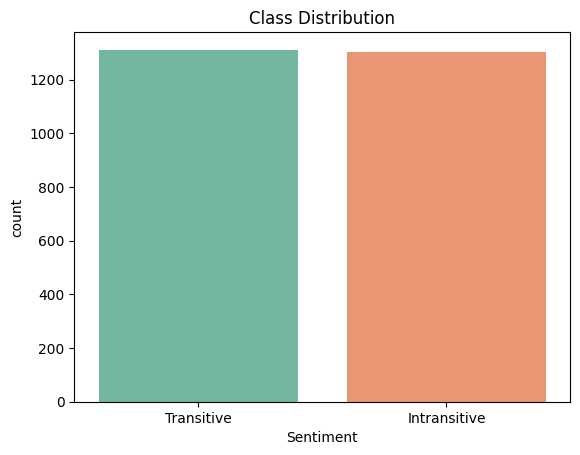

In [ ]:
print(df['Sentiment'].value_counts())

sns.countplot(x='Sentiment', data=df, palette='Set2', hue='Sentiment', legend=False)
plt.title("Class Distribution")
plt.show()

In [ ]:
x = X_tfidf_array
y = Fit_Sentiment

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Total samples:", x.shape[0])
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

Total samples: 2616
Training samples: 2092
Validation samples: 262
Testing samples: 262


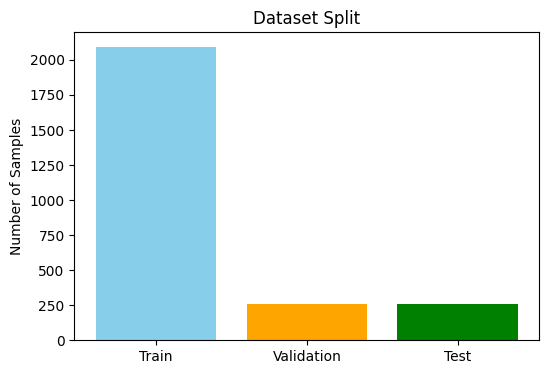

In [ ]:
counts = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Train', 'Validation', 'Test']

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['skyblue', 'orange', 'green'])
plt.title("Dataset Split")
plt.ylabel("Number of Samples")
plt.show()

Accuracy: 0.7213740458015268
              precision    recall  f1-score   support

           0       0.64      0.82      0.72       115
           1       0.82      0.65      0.72       147

    accuracy                           0.72       262
   macro avg       0.73      0.73      0.72       262
weighted avg       0.74      0.72      0.72       262

Confusion Matrix:
 [[94 21]
 [52 95]]


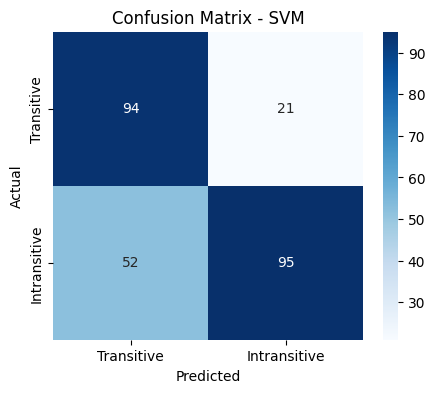

In [ ]:
X = X_tfidf_array
y = Fit_Sentiment

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = LinearSVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Transitive', 'Intransitive'], yticklabels=['Transitive', 'Intransitive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - SVM')
plt.show()

Accuracy: 0.7175572519083969
              precision    recall  f1-score   support

           0       0.64      0.81      0.72       115
           1       0.81      0.65      0.72       147

    accuracy                           0.72       262
   macro avg       0.73      0.73      0.72       262
weighted avg       0.74      0.72      0.72       262

Confusion Matrix:
 [[93 22]
 [52 95]]


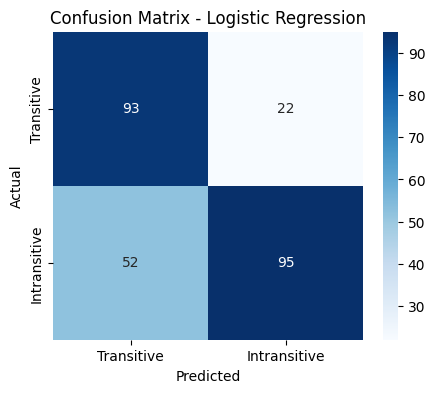

In [ ]:
X = X_tfidf_array
y = Fit_Sentiment

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Transitive', 'Intransitive'], yticklabels=['Transitive', 'Intransitive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
!pip install transformers datasets

In [ ]:
texts = df['clean_Sentence']
labels = y

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

X_train, X_temp, y_train, y_temp = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df = pd.DataFrame({"text": X_val, "label": y_val})
test_df = pd.DataFrame({"text": X_test, "label": y_test})

In [ ]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})


In [ ]:
from transformers import AutoTokenizer

model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/2092 [00:00<?, ? examples/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./banglabert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.147400,0.231802,0.935115,0.935787,0.935115,0.935110
2,0.092500,0.163128,0.969466,0.969890,0.969466,0.969451
3,0.076800,0.227596,0.961832,0.961931,0.961832,0.961825
4,0.008300,0.226525,0.961832,0.961832,0.961832,0.961832
5,0.025400,0.243098,0.958015,0.958047,0.958015,0.958017


TrainOutput(global_step=1310, training_loss=0.10802817728285116, metrics={'train_runtime': 448.471, 'train_samples_per_second': 23.324, 'train_steps_per_second': 2.921, 'total_flos': 688041587358720.0, 'train_loss': 0.10802817728285116, 'epoch': 5.0})


Test Results: {'eval_loss': 0.18698789179325104, 'eval_accuracy': 0.9618320610687023, 'eval_precision': 0.9621271845628552, 'eval_recall': 0.9618320610687023, 'eval_f1': 0.9617504523615973, 'eval_runtime': 2.1637, 'eval_samples_per_second': 121.086, 'eval_steps_per_second': 15.251, 'epoch': 5.0}

Accuracy: 0.9618320610687023

Classification Report:

              precision    recall  f1-score   support

  Transitive       0.97      0.94      0.96       115
Intransitive       0.95      0.98      0.97       147

    accuracy                           0.96       262
   macro avg       0.96      0.96      0.96       262
weighted avg       0.96      0.96      0.96       262


Confusion Matrix:
 [[108   7]
 [  3 144]]


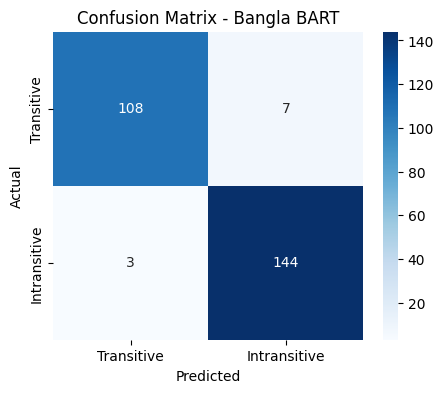

In [ ]:
test_results = trainer.evaluate(tokenized_dataset["test"])
print("\nTest Results:", test_results)

predictions = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = predictions.label_ids

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Transitive", "Intransitive"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Transitive', 'Intransitive'],
    yticklabels=['Transitive', 'Intransitive']
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Bangla BART')
plt.show()
